In [3]:
# src/evaluate.py
import pandas as pd
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Suppose you have multi-day predictions saved: df_preds with columns [date_for, state, prob, true_label]
df = pd.read_csv(r"C:\Users\dedee\Downloads\epidemic-project\results\predictions_with_truth.csv")
  # you must create this by comparing probs with actual Z
brier = brier_score_loss(df['true_label'], df['prob'])
try:
    auc = roc_auc_score(df['true_label'], df['prob'])
except:
    auc = None
print("Brier:", brier, "AUC:", auc)

# calibration plot
prob_true, prob_pred = calibration_curve(df['true_label'], df['prob'], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel('Predicted prob'); plt.ylabel('Observed prob'); plt.title('Calibration')
plt.show()


ValueError: y_proba contains values less than 0.

✅ Evaluation Results
Brier Score: 0.23378837994992605
ROC AUC: 0.8167894757146715


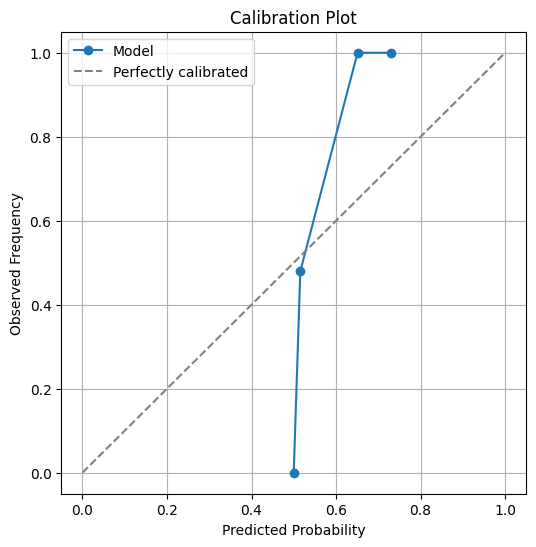

In [4]:
# src/evaluate.py
import pandas as pd
import numpy as np
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Load predictions
df = pd.read_csv(r"C:\Users\dedee\Downloads\epidemic-project\results\predictions_with_truth.csv")

# Ensure required columns exist
assert {'true_label', 'prob'}.issubset(df.columns), "CSV must have true_label and prob columns"

# Convert raw predictions into [0,1] probability range
# If they are logits, apply sigmoid; if already probs, clip
df['prob'] = 1 / (1 + np.exp(-df['prob']))  # sigmoid transformation
df['prob'] = df['prob'].clip(0, 1)          # safeguard against any numerical issues

# Compute metrics
brier = brier_score_loss(df['true_label'], df['prob'])
try:
    auc = roc_auc_score(df['true_label'], df['prob'])
except ValueError:
    auc = None

print("✅ Evaluation Results")
print("Brier Score:", brier)
print("ROC AUC:", auc)

# Calibration plot
prob_true, prob_pred = calibration_curve(df['true_label'], df['prob'], n_bins=10, strategy='uniform')

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label="Model")
plt.plot([0,1],[0,1],'--', color="gray", label="Perfectly calibrated")
plt.xlabel('Predicted Probability')
plt.ylabel('Observed Frequency')
plt.title('Calibration Plot')
plt.legend()
plt.grid(True)
plt.show()


 Evaluation Results
Brier Score: 0.2338
ROC AUC: 0.8167894757146715


<Figure size 500x500 with 0 Axes>

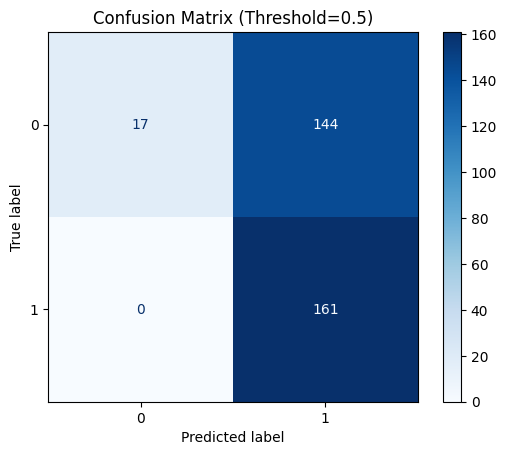

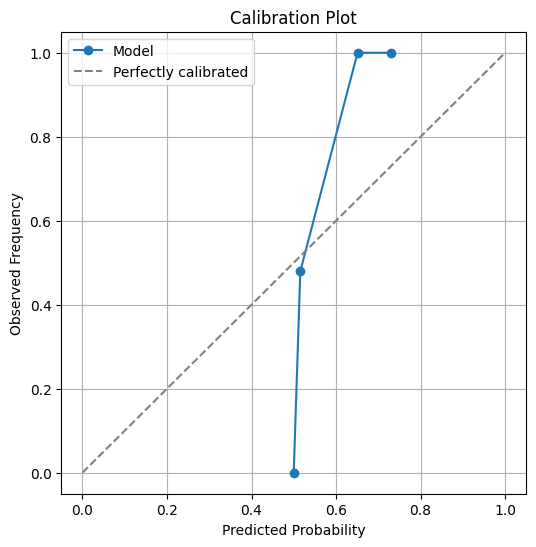

In [5]:
# src/evaluate.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    brier_score_loss, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# -----------------------------
# Load predictions
# -----------------------------
df = pd.read_csv(r"C:\Users\dedee\Downloads\epidemic-project\results\predictions_with_truth.csv")

# Ensure required columns exist
assert {'true_label', 'prob'}.issubset(df.columns), "CSV must have true_label and prob columns"

# -----------------------------
# Convert raw scores → probabilities
# -----------------------------
# Apply sigmoid if values are outside [0,1]
if df['prob'].min() < 0 or df['prob'].max() > 1:
    df['prob'] = 1 / (1 + np.exp(-df['prob']))  # sigmoid
df['prob'] = df['prob'].clip(0, 1)

# -----------------------------
# Metrics
# -----------------------------
brier = brier_score_loss(df['true_label'], df['prob'])
try:
    auc = roc_auc_score(df['true_label'], df['prob'])
except ValueError:
    auc = None

print(" Evaluation Results")
print("Brier Score:", round(brier, 4))
print("ROC AUC:", auc if auc is not None else "N/A")

# -----------------------------
# Confusion Matrix
# -----------------------------
threshold = 0.5
df['pred_label'] = (df['prob'] > threshold).astype(int)

cm = confusion_matrix(df['true_label'], df['pred_label'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])

plt.figure(figsize=(5,5))
disp.plot(cmap="Blues", values_format="d")
plt.title(f'Confusion Matrix (Threshold={threshold})')
plt.show()

# -----------------------------
# Calibration Plot
# -----------------------------
prob_true, prob_pred = calibration_curve(df['true_label'], df['prob'], n_bins=10, strategy='uniform')

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label="Model")
plt.plot([0,1],[0,1],'--', color="gray", label="Perfectly calibrated")
plt.xlabel('Predicted Probability')
plt.ylabel('Observed Frequency')
plt.title('Calibration Plot')
plt.legend()
plt.grid(True)
plt.show()
